## Import Libraries

In [32]:
# utils
import os 
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from pathlib import Path
from google.colab import drive

# torch
import torch
import torch.optim as optim
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import models, datasets



## Reading The Data

In [ ]:
from google.colab import drive
import torch

drive.mount('/content/drive')

base_directory = '/content/drive/MyDrive/Colab Notebooks/DL Project/Data'
train, test = 'Training', 'Testing'
target_size = (224, 224)
random_state = 42
batch_size = 32
num_classes = 4
device = "cuda" if torch.cuda.is_available() else "cpu"
label_map = {
    'notumor': 0,        
    'glioma': 1,         
    'meningioma': 2,     
    'pituitary': 3       
}


 Device       : cuda


In [34]:
categories = os.listdir(base_directory+'/'+train)
print(categories)

['pituitary', 'notumor', 'meningioma', 'glioma']


In [35]:
def display_images(dataset, num_images=4, image_size=(224, 224)):
    
    dataset_path = os.path.join(base_directory, dataset)

    fig, axes = plt.subplots(len(categories), num_images, figsize=(15, 10))

    for row, category in enumerate(categories):
        category_path = os.path.join(dataset_path, category)
        image_filenames = random.sample(os.listdir(category_path), num_images)  
        
        for col, image_filename in enumerate(image_filenames):
            while image_filename == '.DS_Store':
                image_filename = random.sample(os.listdir(category_path), 1)[0]
            image_path = os.path.join(category_path, image_filename)
            image = Image.open(image_path).resize(image_size)
            axes[row, col].imshow(image, cmap='gray')
            axes[row, col].axis('off')
            axes[row, col].set_title(f"{category}")

    plt.tight_layout()
    plt.show()

### Exploring the Data

In [40]:
def plot_class_distribution(dataset):
    path = os.path.join(base_directory, dataset)
    counts = [len(os.listdir(os.path.join(path, cat))) for cat in categories]

    plt.bar(categories, counts, color = ['navy', 'teal', 'darkorange', 'crimson'])
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.title(f"{dataset.capitalize()} Data Distribution")
    plt.show()

### Train set

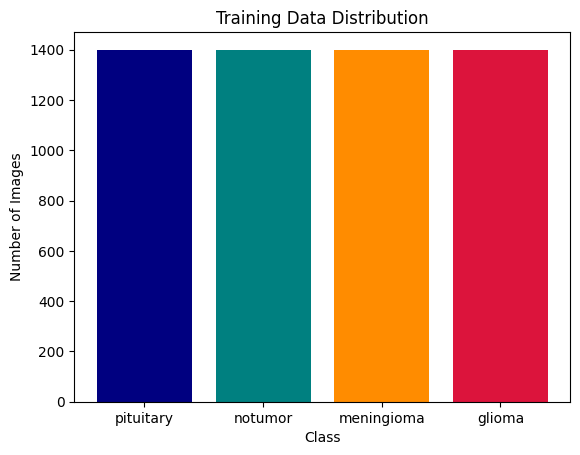

In [41]:
plot_class_distribution(train)

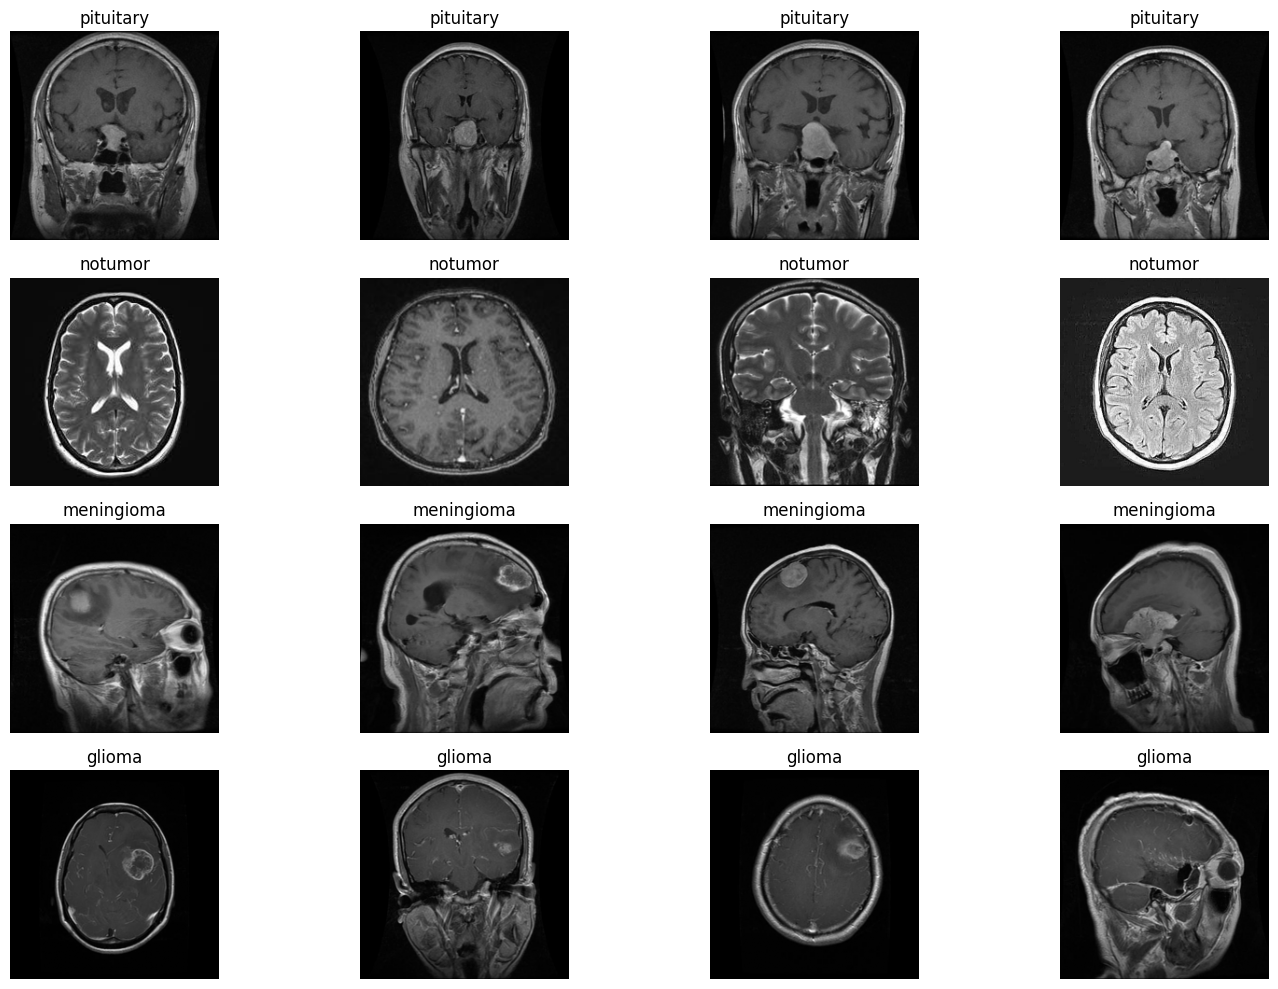

In [42]:
display_images(train)

### Test Set

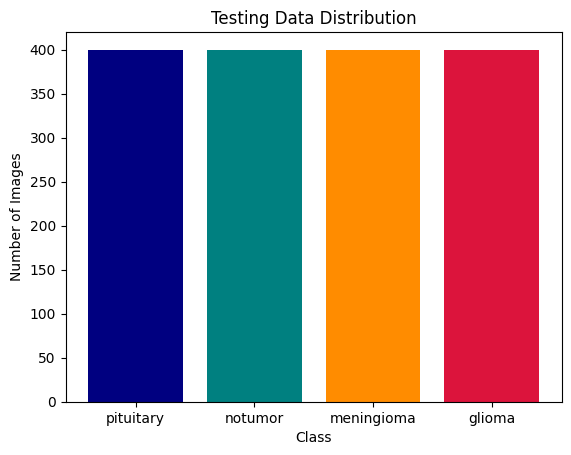

In [43]:
plot_class_distribution(test)

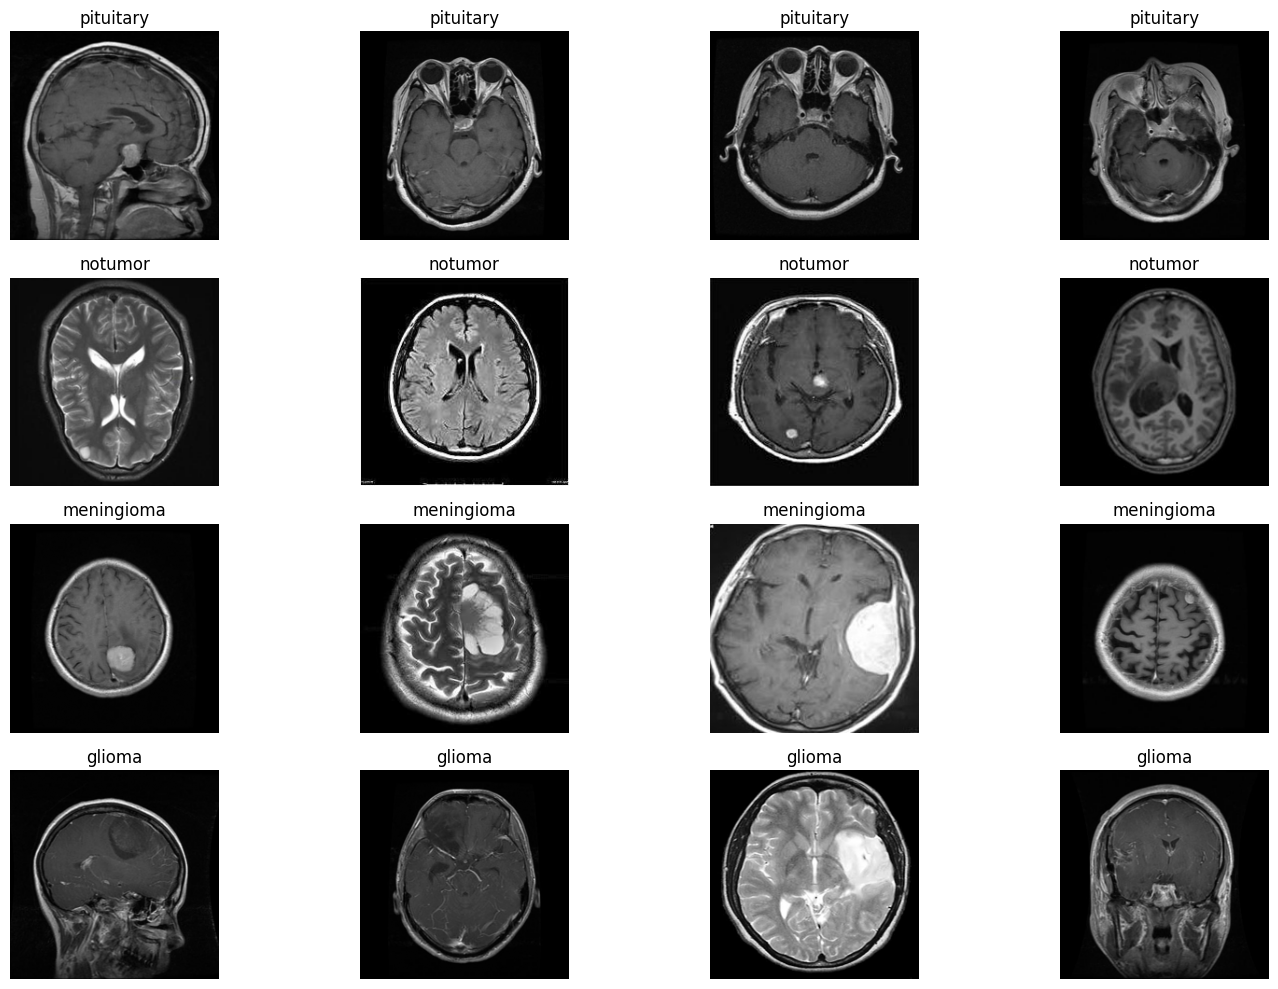

In [44]:
display_images(test)

## Preparing the Data

In [45]:
def create_dataset(path):
    my_list = []
    for category in categories:
        category_path = os.path.join(path, category)
        for file_name in os.listdir(category_path):
            file_path = os.path.join(category_path, file_name)

            if os.path.isfile(file_path) and file_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                my_list.append([file_path, category])
    return pd.DataFrame(my_list, columns=['file_path', 'label'])

In [46]:
train_df = create_dataset(base_directory+'/'+train)
test_df = create_dataset(base_directory+'/'+test)

In [47]:
train_df['label'] = train_df['label'].map(label_map)
test_df['label'] = test_df['label'].map(label_map)

### Create Class ImageDataset

In [48]:
class ImageDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform
        
    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx, 0]
        label = self.dataframe.iloc[idx, 1]
        img = Image.open(img_path).convert('RGB')  

        if self.transform:
            img = self.transform(img)
            
        return img, label

### Data Augmentation

In [49]:
train_transform = transforms.Compose([

   transforms.Resize(target_size),
   transforms.RandomHorizontalFlip(),
   transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
   transforms.ColorJitter(brightness=(0.8, 1.2)),
   transforms.RandomRotation(10),
   transforms.ToTensor(),
   transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [50]:
test_df_split, val_df_split = train_test_split(test_df, test_size=0.5, random_state=random_state)

test_df_split = test_df_split.reset_index(drop=True)
val_df_split = val_df_split.reset_index(drop=True)

In [51]:
train_dataset = ImageDataset(train_df, transform=train_transform)
val_dataset = ImageDataset(val_df_split, transform=test_transform)
test_dataset = ImageDataset(test_df_split, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Model 1 (Custom CNN)

In [ ]:
class BrainTumorCNN(nn.Module):
    def __init__(self, num_classes=4):
        super(BrainTumorCNN, self).__init__()
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Conv Block 1
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)    # (B, 32, 224, 224)
        self.bn1   = nn.BatchNorm2d(32)                             # Normalize Conv1 output
        # Conv Block 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)   # (B, 64, 112, 112)
        self.bn2   = nn.BatchNorm2d(64)                             # Normalize Conv2 output
        # Conv Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)  # (B, 128, 56, 56)
        self.bn3   = nn.BatchNorm2d(128)                            # Normalize Conv3 output
        # Conv Block 4
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1) # (B, 256, 28, 28)
        self.bn4   = nn.BatchNorm2d(256)                            # Normalize Conv4 output
        # Conv Block 5
        self.conv5 = nn.Conv2d(256, 256, kernel_size=3, padding=1) # (B, 256, 14, 14)
        self.bn5   = nn.BatchNorm2d(256)                            # Normalize Conv5 output

        # Final shape after pool: (B, 256, 7, 7)
        self.flatten  = nn.Flatten()
        self.fc1      = nn.Linear(256 * 7 * 7, 512)
        self.bn_fc    = nn.BatchNorm1d(512)                         # Normalize FC1 output
        self.dropout1 = nn.Dropout(0.4)                             # Regularize after FC1
        self.fc2      = nn.Linear(512, 256)                         
        self.dropout2 = nn.Dropout(0.3)                             
        self.fc3      = nn.Linear(256, num_classes)                 

    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))  # (B, 32, 112, 112)
        x = self.pool(self.relu(self.bn2(self.conv2(x))))  # (B, 64, 56, 56)
        x = self.pool(self.relu(self.bn3(self.conv3(x))))  # (B, 128, 28, 28)
        x = self.pool(self.relu(self.bn4(self.conv4(x))))  # (B, 256, 14, 14)
        x = self.pool(self.relu(self.bn5(self.conv5(x))))  # (B, 256, 7, 7)
        x = self.flatten(x)
        x = self.dropout1(self.relu(self.bn_fc(self.fc1(x))))  # FC1 -> BN -> ReLU -> Dropout
        x = self.dropout2(self.relu(self.fc2(x)))              # FC2 -> ReLU -> Dropout
        x = self.fc3(x)                                        
        return x

In [54]:
model = BrainTumorCNN(num_classes=4).to(device) 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-4)

In [55]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50, name='model', patience=15):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    best_val_acc = 0.0
    tolerance = 0
    TARGET_ACC = 99.0

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='max', factor=0.5, patience=4
    )

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        # Training phase
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_loss = running_loss / len(train_loader)
        train_acc = 100 * correct_train / total_train

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_loss = val_loss / len(val_loader)
        val_acc = 100 * correct_val / total_val

        # Step scheduler based on val_acc
        scheduler.step(val_acc)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch [{epoch+1}/{num_epochs}] | LR: {current_lr:.6f}")
        print(f"Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%")
        print(f"Val   Loss: {val_loss:.4f}, Val   Accuracy: {val_acc:.2f}%")
        print("#" * 80)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'best_brain_tumor_{name}.pth')
            tolerance = 0
            print(f" Best model saved (val_acc: {val_acc:.2f}%)")
        else:
            tolerance += 1
            print(f"  No improvement. Patience: {tolerance}/{patience}")

        
        if train_acc >= TARGET_ACC and val_acc >= TARGET_ACC:
            print(f" Target reached Train: {train_acc:.2f}% | Val: {val_acc:.2f}% — Stopping.")
            break

        if tolerance >= patience:
            if current_lr <= 1e-6:
                print(f" Early stopping: no improvement after {epoch+1} epochs and LR exhausted.")
                break
            else:
                print(f" Patience hit but LR still has room — resetting patience counter.")
                tolerance = 0 

    return history

In [ ]:
def test_model(model, test_loader, num_images_to_show=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()
    
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    all_images = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_images.extend(images.cpu()) 

    test_acc = 100 * correct / total

    cm = confusion_matrix(all_labels, all_preds)

    print(f"Test Accuracy: {test_acc:.2f}%\n")
    
    print("Classification Report:\n")
    print(classification_report(all_labels, all_preds, target_names=categories))

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=categories, yticklabels=categories)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [57]:
print("Starting training...")
history = train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=50)

Starting training...
Epoch [1/50] | LR: 0.000700
Train Loss: 0.6663, Train Accuracy: 72.43%
Val   Loss: 0.8158, Val   Accuracy: 75.62%
################################################################################
 Best model saved (val_acc: 75.62%)
Epoch [2/50] | LR: 0.000700
Train Loss: 0.4530, Train Accuracy: 83.21%
Val   Loss: 0.7946, Val   Accuracy: 73.88%
################################################################################
  No improvement. Patience: 1/15
Epoch [3/50] | LR: 0.000700
Train Loss: 0.3946, Train Accuracy: 84.79%
Val   Loss: 0.7227, Val   Accuracy: 78.62%
################################################################################
 Best model saved (val_acc: 78.62%)
Epoch [4/50] | LR: 0.000700
Train Loss: 0.3429, Train Accuracy: 87.34%
Val   Loss: 0.4825, Val   Accuracy: 84.25%
################################################################################
 Best model saved (val_acc: 84.25%)
Epoch [5/50] | LR: 0.000700
Train Loss: 0.3096, Train Accu

In [58]:
def plot_training_history(history, model_name="model"):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.show()

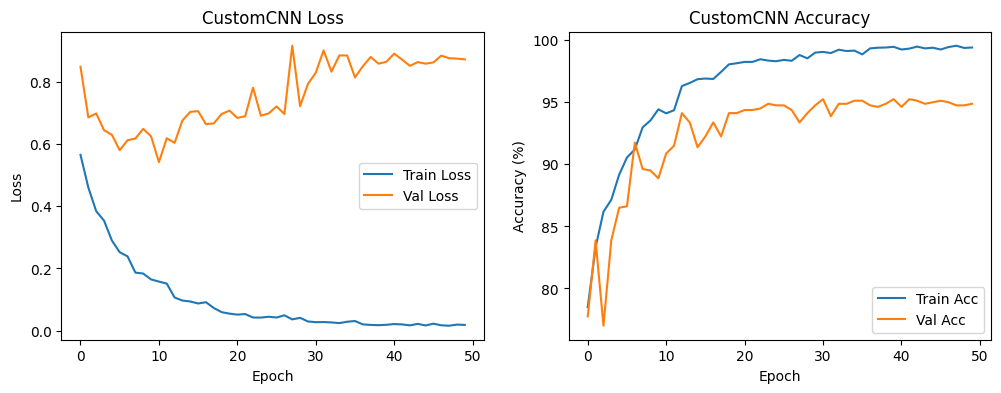

In [30]:
plot_training_history(history, model_name="CustomCNN")

## Evaluation


Loading best model for testing...
Test Accuracy: 94.38%

Classification Report:

              precision    recall  f1-score   support

   pituitary       0.89      1.00      0.94       196
     notumor       1.00      0.81      0.90       202
  meningioma       0.92      0.97      0.94       214
      glioma       0.99      1.00      0.99       188

    accuracy                           0.94       800
   macro avg       0.95      0.94      0.94       800
weighted avg       0.95      0.94      0.94       800



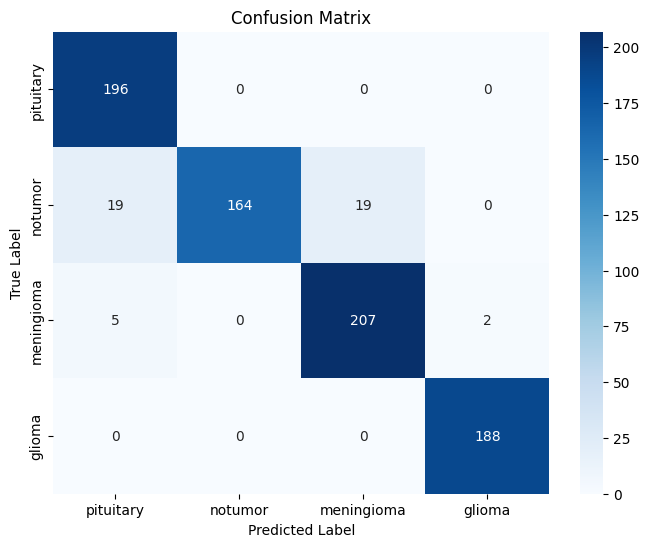

In [59]:
print("\nLoading best model for testing...")
model.load_state_dict(torch.load('best_brain_tumor_model.pth'))
test_model(model, test_loader)

In [60]:
def visualize_predictions(model, test_loader, num_images=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    correct_images, incorrect_images = [], []
    correct_labels, incorrect_labels = [], []
    correct_preds, incorrect_preds = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            for i in range(len(predicted)):
                if predicted[i] == labels[i]:
                    correct_images.append(images[i])
                    correct_labels.append(labels[i].cpu().item())
                    correct_preds.append(predicted[i].cpu().item())
                else:
                    incorrect_images.append(images[i])
                    incorrect_labels.append(labels[i].cpu().item())
                    incorrect_preds.append(predicted[i].cpu().item())

  
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

    num_cols = num_images // 2
    plt.figure(figsize=(15, 7))

    for i, img_tensor in enumerate(correct_images[:num_images // 2]):
        img_tensor = img_tensor * std + mean  # reverse normalization
        img = np.clip(img_tensor.permute(1, 2, 0).cpu().numpy(), 0, 1)
        plt.subplot(2, num_cols, i + 1)
        plt.imshow(img)
        plt.title(f"True: {categories[correct_labels[i]]}\nPred: {categories[correct_preds[i]]}", color='green', fontsize=15)
        plt.axis('off')

    for i, img_tensor in enumerate(incorrect_images[:num_images // 2]):
        if i >= len(incorrect_images):
            plt.axis('off')
            continue
        img_tensor = img_tensor * std + mean  # reverse normalization
        img = np.clip(img_tensor.permute(1, 2, 0).cpu().numpy(), 0, 1)
        plt.subplot(2, num_cols, num_cols + i + 1)
        plt.imshow(img)
        plt.title(f"True: {categories[incorrect_labels[i]]}\nPred: {categories[incorrect_preds[i]]}", color='red', fontsize=15)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

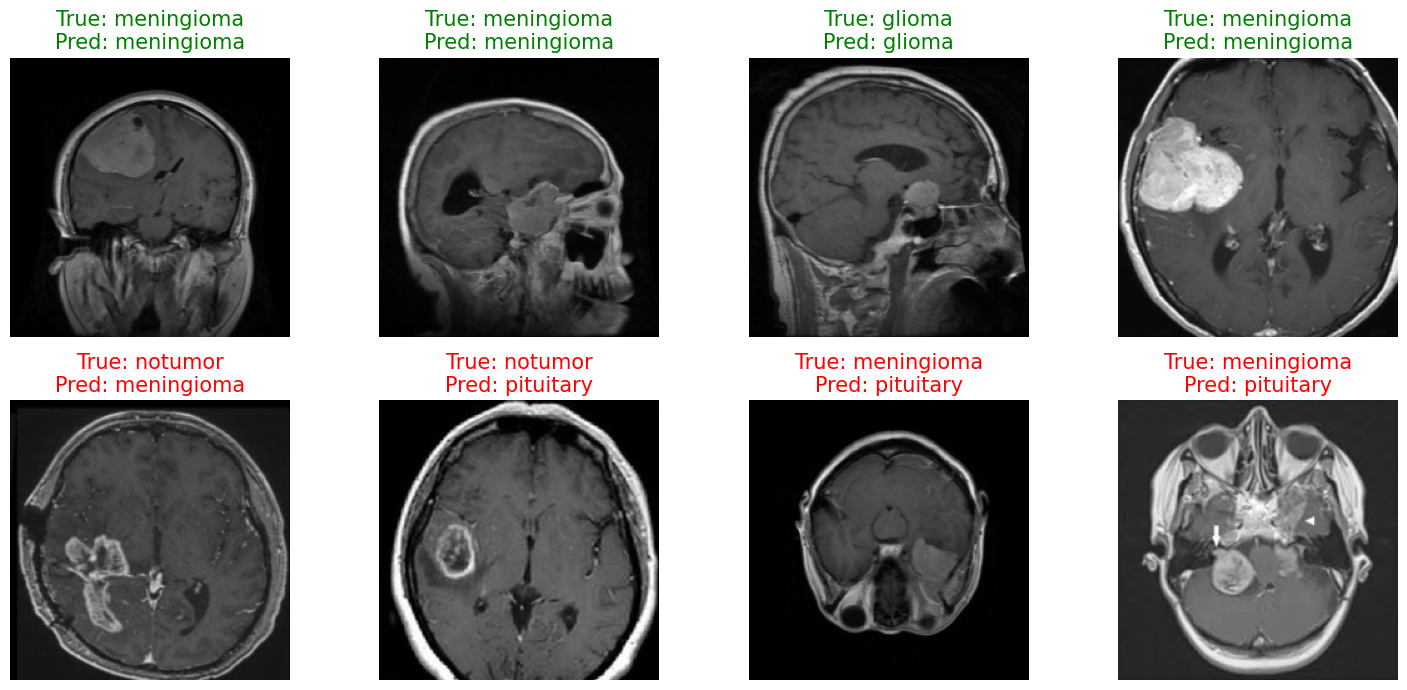

In [61]:
visualize_predictions(model, test_loader, 8)